# Daisyworld Demo

Minimal example for the `Daisyworld` model in `paleobeasts.signal_models`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb
from paleobeasts.signal_models import Daisyworld

In [3]:
t_span = (0, 80)
y0 = [0.2, 0.2, 288.0]

model_unforced = Daisyworld(forcing=None, L=1.0)
model_unforced.integrate(t_span=t_span, y0=y0, method='RK45')

luminosity_forcing = pb.Forcing(lambda t: 0.08 * np.sin(2 * np.pi * t / 20.0))
model_forced = Daisyworld(forcing=luminosity_forcing, L=1.0)
model_forced.integrate(t_span=t_span, y0=y0, method='RK45')

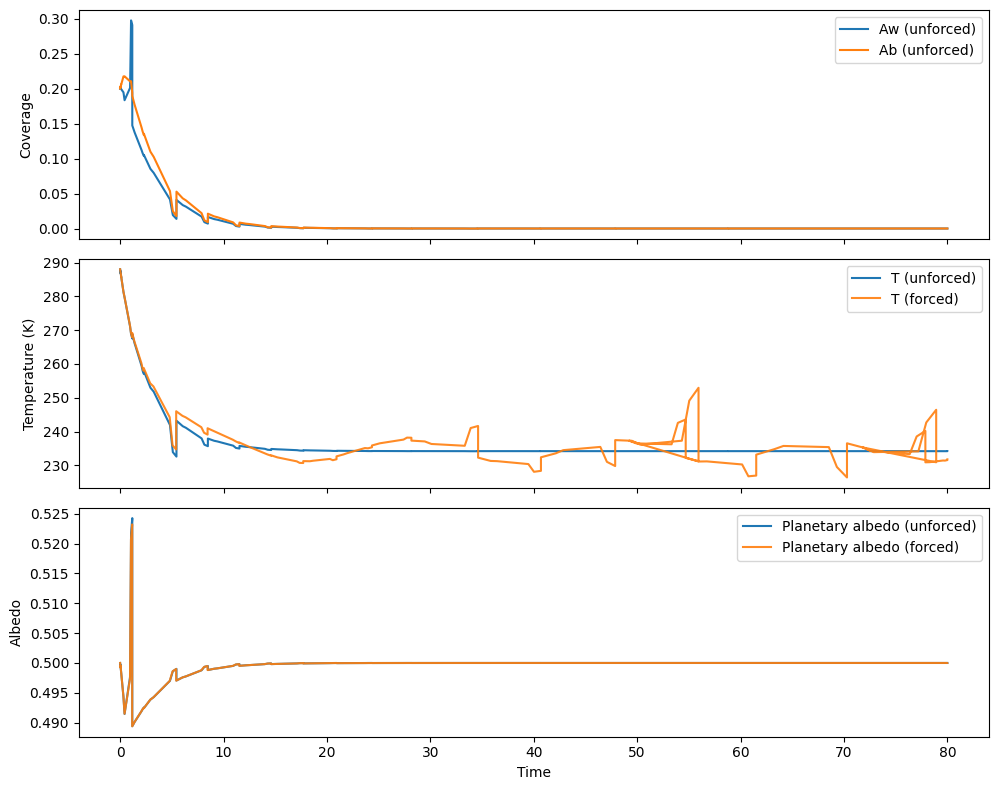

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(model_unforced.time, model_unforced.state_variables['Aw'], label='Aw (unforced)')
ax[0].plot(model_unforced.time, model_unforced.state_variables['Ab'], label='Ab (unforced)')
ax[0].set_ylabel('Coverage')
ax[0].legend()

ax[1].plot(model_unforced.time, model_unforced.state_variables['T'], label='T (unforced)')
ax[1].plot(model_forced.time, model_forced.state_variables['T'], label='T (forced)', alpha=0.9)
ax[1].set_ylabel('Temperature (K)')
ax[1].legend()

ax[2].plot(model_unforced.time, model_unforced.diagnostic_variables['A_planet'], label='Planetary albedo (unforced)')
ax[2].plot(model_forced.time, model_forced.diagnostic_variables['A_planet'], label='Planetary albedo (forced)', alpha=0.9)
ax[2].set_ylabel('Albedo')
ax[2].set_xlabel('Time')
ax[2].legend()

plt.tight_layout()
plt.show()